# Customer Churn Analysis

## Business problem

Customer churn is a major problem for subscription business. 
Losing customers increases aquisition costs and reduces revenue.

This project analyzes customer data behavior to identify factors associated with churn
and build predictive model to identify customer at risks of leaving.

## Objective

1. Understand customer churn patterns through exploratory data analysis.
2. Identify key factors that influence customer churn.
3. Build an interpretable churn prediction model.
4. Translate model findings into actionable retention strategies.

## Dataset

Dataset:

https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Target variable:

`churn`

Goal:

Predict whether a customer is likely to leave to the service.


# 1. Import Libraries

We import the main Python Libraries needed for:

- Data manipulation
- Data visualization
- Machine learning preparation


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


# 2. Load Dataset

The first step is to load the customer churn dataset and understand its structure.

We will check:

- Number of rows and colunms
- Colunm names
- Data types
- Missing values
- Basic statistics

In [39]:
import os

data_path = "../data/raw/Telco-Customer-Churn.csv"

df = pd.read_csv(data_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
df.shape

(7043, 21)

# 3. Dataset Overview

Before analysis, we need to understand:

- Colunm data types
- Missing values
- Potential data quality issues

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [42]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

(df == " ").sum()

# 4. Data Cleaning

The data contains 11 blank values in `TotalCharges`.

These values are converted to missing values and removed because they represent a very portion of the dataset.

In [43]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [44]:
df = df.dropna()

df.shape

(7032, 21)

In [45]:
df.duplicated().sum()

np.int64(0)

# 5. Target Variable Analysis

Understanding the distribution of churn is important because it determines:

- How balanced the dataset is
- Which evaluation metrics we should prioritize
- How common customer churn is

In [46]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

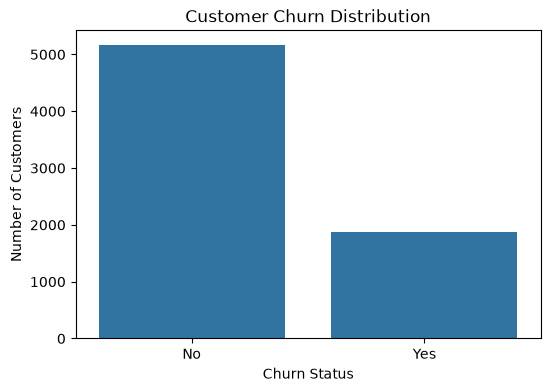

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

In [48]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

# 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand customer behavior and identify
patterns associated with churn.

We will analyze churn across:

- Customer demographics
- Service usage
- Contract information
- Payment behavior
- Charges

## 1. Does contract type affect churn?

In [49]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


## Insight: Contract Type is Strongly Associated With Churn

Customers with month-to-month contracts have the highest churn rate at 42.7%.

Customers with longer commitments show significantly lower churn:
- One-year contracts: 11.3% churn
- Two-year contracts: 2.8% churn

This suggests that contract commitment is an important factor in customer retention.
The business may reduce churn by encouraging high-risk customers to move from
month-to-month plans to longer-term contracts through targeted incentives.

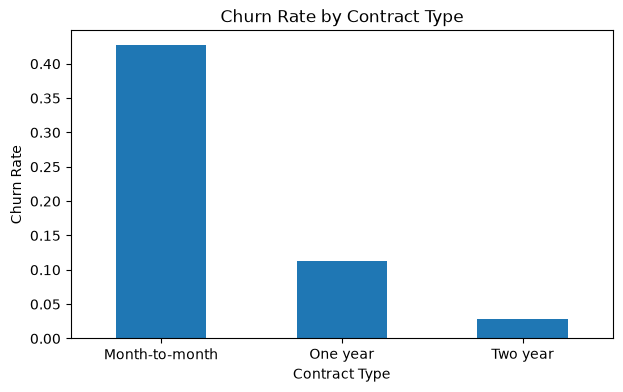

In [50]:
contract_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.xticks(rotation=0)

plt.show()

## Insight: Contract Type and Churn

Contract type is strongly associated with customer churn.

Month-to-month customers have the highest churn rate (42.7%), compared with customers on one-year contracts (11.3%) and two-year contracts (2.8%).

This indicates that customers with flexible contracts represent a higher-risk segment. The business could reduce churn by targeting month-to-month customers with retention offers, loyalty benefits, or incentives to move to longer-term contracts.

## 2. Do newer customers leave more often than long-term customers?

In [51]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

## Customer Tenure Segmentation

To better understand churn behavior, we group customers into tenure ranges.

This helps identify whether new customers or long-term customers are more likely to churn.

In [52]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

df["tenure_group"].value_counts()

tenure_group
49-72 months    2239
0-12 months     2175
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

In [53]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
)

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,0.523218,0.476782
13-24 months,0.712891,0.287109
25-48 months,0.796110,0.203890
49-72 months,0.904868,0.095132


## Insight: Customer Tenure and Churn

Customer tenure is strongly associated with churn risk.

Customers in their first 12 months have the highest churn rate at 47.7%, while long-term customers with 49–72 months of tenure have a much lower churn rate of 9.5%.

This indicates that early customer experience is a critical retention period. The business should focus onboarding improvements, proactive support, and early engagement campaigns on new customers.

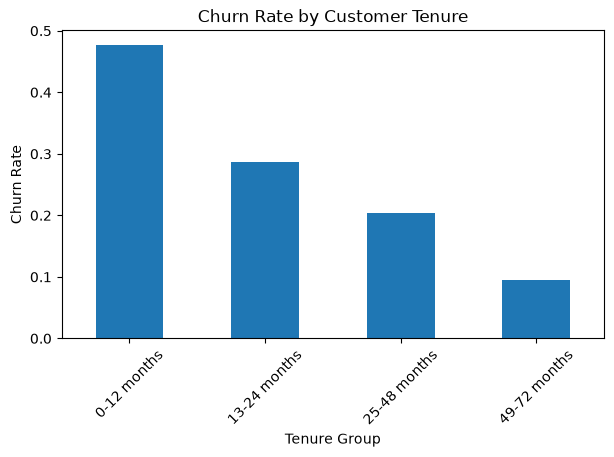

In [54]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group")
plt.xticks(rotation=45)

plt.show()

## Insight: Customer Tenure and Churn

Customer tenure is strongly associated with churn risk.

Customers in their first 12 months have the highest churn rate at 47.7%, while long-term customers with 49–72 months of tenure have a much lower churn rate of 9.5%.

This indicates that early customer experience is a critical retention period. The business should focus onboarding improvements, proactive support, and early engagement campaigns on new customers.

## 3. Does Payment Method Affect Churn?

Payment method may reveal differences in customer behavior and retention risk.

We compare churn rates across payment methods.

In [55]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832685,0.167315
Credit card (automatic),0.847469,0.152531
Electronic check,0.547146,0.452854
Mailed check,0.807980,0.192020


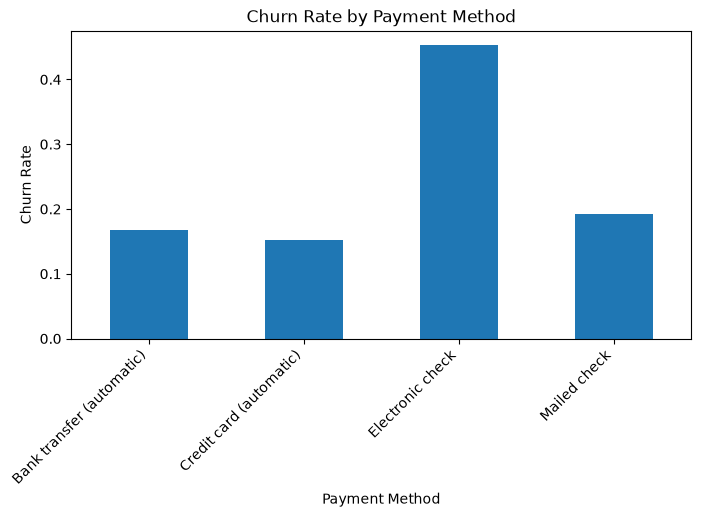

In [56]:
payment_churn["Yes"].plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.xticks(rotation=45, ha="right")

plt.show()

## Insight: Payment Method and Churn

Payment method is associated with significant differences in churn behavior.

Customers using electronic checks have the highest churn rate at 45.3%, compared with customers using automatic bank transfer (16.7%) and automatic credit card payments (15.3%).

This suggests that electronic check customers represent a higher-risk segment. The business could investigate billing friction and encourage customers to adopt automatic payment methods through incentives or improved payment experiences.

## 4. Do Monthly Charges Affect Churn?

Monthly charges represent the customer's recurring cost.

We compare monthly charge distributions between customers who stayed and customers who churned.

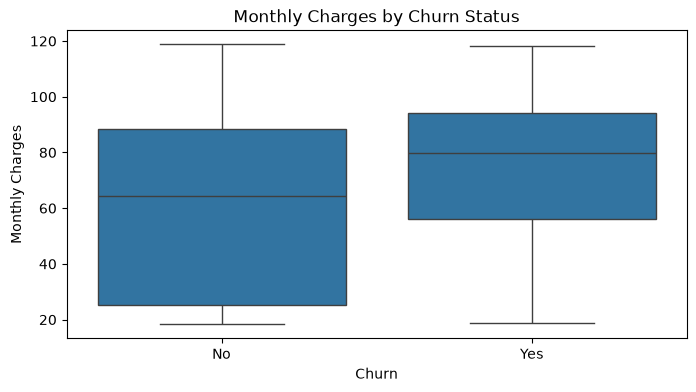

In [57]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [58]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

## Insight: Monthly Charges and Churn

Monthly charges are associated with customer churn.

Customers who churn have a higher average monthly charge ($74.44) compared with customers who stay ($61.31).

This suggests that higher-paying customers may have increased price sensitivity or higher expectations from the service. The business should investigate whether premium customers are receiving enough value and consider targeted retention offers for high-value customers.

## 5. Does Tech Support Affect Churn?

Customer support availability may influence retention.

We compare churn rates between customers with and without technical support.

In [59]:
tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,0.583525,0.416475
No internet service,0.925658,0.074342
Yes,0.848039,0.151961


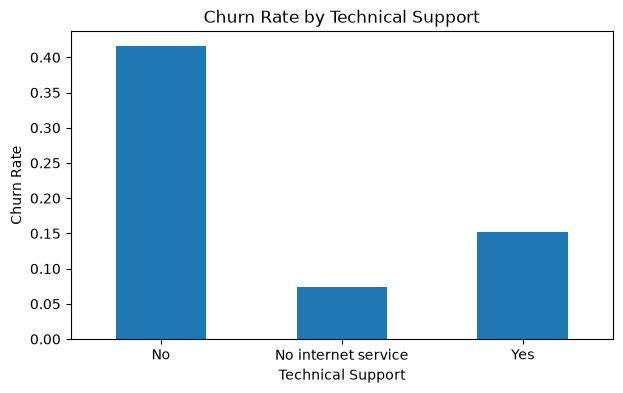

In [60]:
tech_support_churn["Yes"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Churn Rate by Technical Support")
plt.ylabel("Churn Rate")
plt.xlabel("Technical Support")
plt.xticks(rotation=0)

plt.show()

## Insight: Technical Support and Churn

Technical support availability is strongly associated with customer churn.

Customers without technical support have a churn rate of 41.6%, compared with 15.2% for customers who have technical support.

This suggests that customers without support services represent a higher-risk segment. The business could improve retention by promoting support services and proactively assisting customers who may be experiencing service issues.

# EDA Summary: Key Churn Drivers

Based on exploratory analysis, several customer characteristics show strong associations with churn.

## Main Findings

1. **Contract Type**

   Month-to-month customers have the highest churn rate (42.7%), while customers with two-year contracts have a much lower churn rate (2.8%). Longer customer commitments are associated with better retention.

2. **Customer Tenure**

   Customers in their first 12 months have the highest churn risk, with a churn rate of 47.7%. Early customer experience appears to be a critical retention period.

3. **Payment Method**

   Customers using electronic checks have a higher churn rate (45.3%) compared with customers using automatic payment methods. Payment behavior may indicate differences in customer engagement and billing experience.

4. **Monthly Charges**

   Customers who churn have higher average monthly charges ($74.44) compared with customers who stay ($61.31). Higher-paying customers may require additional attention to ensure they receive enough value.

5. **Technical Support**

   Customers without technical support have a higher churn rate (41.6%) compared with customers who have technical support (15.2%). Support availability is associated with stronger customer retention.

## Modeling Direction

These findings will guide the next stage of the project:

- Use customer demographics, services, contract details, and billing information as model features.
- Build a classification model to predict customers with high churn risk.
- Analyze feature importance to identify the strongest churn predictors.